# Data Inspection

Use this notebook for exploration and visualization. Keep repeatable cleaning/imputation logic in `scripts/model_cleaning.py` and run it with `scripts/clean_model_data.py`.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
except ImportError:
    sns = None

ROOT = Path.cwd()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
elif not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

SCRIPTS_DIR = ROOT / "scripts"
DATA_PATH = ROOT / "data" / "processed" / "alonhadat_features.csv"
CLEANED_PATH = ROOT / "data" / "processed" / "real_estate_cleaned.csv"
for path in [ROOT, SCRIPTS_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"Project root: {ROOT}")
print(f"Scripts dir: {SCRIPTS_DIR}")
print(f"Input exists: {DATA_PATH.exists()} -> {DATA_PATH}")


Project root: d:\School\Kỳ 8\DSP391m\Codes\Real-Estate-Valuation
Scripts dir: d:\School\Kỳ 8\DSP391m\Codes\Real-Estate-Valuation\scripts
Input exists: True -> d:\School\Kỳ 8\DSP391m\Codes\Real-Estate-Valuation\data\processed\alonhadat_features.csv


In [2]:
# Human-readable VND display helpers for inspection only.
def format_billion_vnd(value):
    if pd.isna(value):
        return pd.NA
    return f"{value / 1_000_000_000:,.2f} tỷ"


def format_million_vnd(value):
    if pd.isna(value):
        return pd.NA
    return f"{value / 1_000_000:,.1f} triệu"


def add_readable_price_columns(frame):
    frame = frame.copy()
    if "price_vnd" in frame.columns:
        frame["price_billion_vnd"] = frame["price_vnd"] / 1_000_000_000
        frame["price_display"] = frame["price_vnd"].map(format_billion_vnd)
    if "price_per_m2" in frame.columns:
        frame["price_per_m2_million_vnd"] = frame["price_per_m2"] / 1_000_000
        frame["price_per_m2_display"] = frame["price_per_m2"].map(format_million_vnd)
    return frame


In [3]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(2082, 44)


,link,title,post_day,street,old_address,locality,region,listing_id,direction,listing_type,...,nearest_marketplace_km,marketplace_count_3km,nearest_supermarket_km,supermarket_count_3km,nearest_mall_km,mall_count_3km,nearest_bus_stop_km,bus_stop_count_1km,nearest_metro_km,metro_count_5km
0,https://alonhadat.com.vn/ban-nha-rieng-hem-xe-...,Bán nhà riêng hẻm xe hơi 4 tầng mới đẹp lung l...,2026-05-23,đường lê quang định,"Đường Lê Quang Định, Phường 14, Quận Bình Thạn...",phường bình thạnh,hồ chí minh,18269430,unknown,can_ban,...,0.317341,16.0,0.127429,61.0,3.067853,0.0,0.108269,47.0,2.080087,7.0
1,https://alonhadat.com.vn/sieu-vi-tri-toa-nha-h...,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,2026-05-27,đường lê thánh tôn,"Đường Lê Thánh Tôn, Phường Bến Nghé, Quận 1, H...",phường sài gòn,hồ chí minh,17891053,unknown,can_ban,...,0.915369,22.0,0.331273,97.0,0.690744,15.0,0.089534,68.0,0.352320,7.0
2,https://alonhadat.com.vn/ban-biet-thu-khu-comp...,Bán Biệt Thự Khu Compound 284 Nguyễn Trọng Tuy...,2026-05-27,đường nguyễn trọng tuyển,"Đường Nguyễn Trọng Tuyển, Phường 10, Quận Phú ...",phường phú nhuận,hồ chí minh,16693368,unknown,can_ban,...,0.571107,19.0,0.256364,53.0,1.945494,6.0,0.155312,47.0,3.900285,4.0
3,https://alonhadat.com.vn/-ban-gap-can-nha-ngay...,🔥🔥🔥Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang ch...,2026-06-10,đường trịnh như khuê,"Đường Trịnh Như Khuê, Xã Bình Chánh, Huyện Bìn...",xã bình chánh,hồ chí minh,18261891,unknown,can_ban,...,0.254834,1.0,NaN,0.0,NaN,0.0,0.125159,12.0,NaN,0.0
4,https://alonhadat.com.vn/chu-sap-dinh-cu-nuoc-...,CHỦ SẮP ĐỊNH CƯ NƯỚC NGOÀI GIẢM SỐC 2 TỶ - BÁN...,2026-06-10,đường nguyễn phi khanh,"Đường Nguyễn Phi Khanh, Phường Tân Định, Quận ...",phường tân định,hồ chí minh,18765886,unknown,can_ban,...,0.291783,27.0,0.124817,100.0,1.475433,13.0,0.122047,50.0,2.031141,6.0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2082 entries, 0 to 2081
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   link                         2082 non-null   str    
 1   title                        2082 non-null   str    
 2   post_day                     2082 non-null   str    
 3   street                       2082 non-null   str    
 4   old_address                  2082 non-null   str    
 5   locality                     2082 non-null   str    
 6   region                       2082 non-null   str    
 7   listing_id                   2082 non-null   int64  
 8   direction                    2082 non-null   str    
 9   listing_type                 2082 non-null   str    
 10  property_type                2082 non-null   str    
 11  legal_status                 2082 non-null   str    
 12  num_floors                   2014 non-null   float64
 13  num_bedrooms                 

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({"missing_count": missing, "missing_percent": missing_percent})
missing_table[missing_table["missing_count"] > 0]


,missing_count,missing_percent
nearest_metro_km,795,38.184438
length_m,267,12.824207
width_m,221,10.614793
nearest_mall_km,83,3.986551
num_floors,68,3.266090
num_bedrooms,61,2.929875
nearest_supermarket_km,30,1.440922
locality_square,16,0.768492
locality_population_density,16,0.768492
road_width_m,14,0.672430


In [6]:
numeric_cols = df.select_dtypes(include="number").columns
summary = df[numeric_cols].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
listing_id,2082.0,1.797581e+07,1.407373e+06,5.761815e+06,1.781653e+07,1.861021e+07,1.877010e+07,1.877399e+07
num_floors,2014.0,3.658888e+00,2.021083e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,2.000000e+01
num_bedrooms,2021.0,7.281544e+00,1.222740e+01,1.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,2.000000e+02
road_width_m,2068.0,1.475479e+01,1.405733e+01,1.000000e+00,6.000000e+00,1.000000e+01,2.000000e+01,2.210000e+02
width_m,1861.0,7.130054e+00,6.336201e+00,2.100000e+00,4.000000e+00,5.000000e+00,8.000000e+00,1.020000e+02
length_m,1815.0,2.035165e+01,1.159244e+01,1.000000e+00,1.500000e+01,1.850000e+01,2.300000e+01,2.020000e+02
price_vnd,2082.0,3.952024e+10,7.599358e+10,8.300000e+01,8.525000e+09,1.700000e+10,3.900000e+10,1.100000e+12
area_m2,2082.0,1.756811e+02,3.565081e+02,9.000000e+00,6.500000e+01,9.500000e+01,1.607500e+02,7.020000e+03
dining_room_bin,2082.0,3.683958e-01,4.824854e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
kitchen_bin,2082.0,3.799232e-01,4.854840e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


In [7]:
df_plot = df.dropna(subset=["price_vnd", "area_m2"]).copy()
df_plot = df_plot[(df_plot["price_vnd"] > 0) & (df_plot["area_m2"] > 0)]
df_plot["price_per_m2"] = df_plot["price_vnd"] / df_plot["area_m2"]
df_plot["price_billion_vnd"] = df_plot["price_vnd"] / 1_000_000_000
df_plot["price_per_m2_million_vnd"] = df_plot["price_per_m2"] / 1_000_000
df_plot[["price_vnd", "price_billion_vnd", "area_m2", "price_per_m2", "price_per_m2_million_vnd"]].describe()


,price_vnd,price_billion_vnd,area_m2,price_per_m2,price_per_m2_million_vnd
count,2.082000e+03,2.082000e+03,2082.000000,2.082000e+03,2082.000000
mean,3.952024e+10,3.952024e+01,175.681076,2.287181e+08,228.718107
std,7.599358e+10,7.599358e+01,356.508136,1.861547e+08,186.154723
min,8.300000e+01,8.300000e-08,9.000000,1.000000e+00,0.000001
25%,8.525000e+09,8.525000e+00,65.000000,1.130815e+08,113.081502
50%,1.700000e+10,1.700000e+01,95.000000,1.777778e+08,177.777778
75%,3.900000e+10,3.900000e+01,160.750000,2.817441e+08,281.744071
max,1.100000e+12,1.100000e+03,7020.000000,2.156863e+09,2156.862745


In [8]:
# Easier-to-read price preview.
df_readable = add_readable_price_columns(df_plot)
readable_cols = [
    "title",
    "locality",
    "area_m2",
    "price_display",
    "price_per_m2_display",
]

df_readable[readable_cols].head(10)


,title,locality,area_m2,price_display,price_per_m2_display
0,Bán nhà riêng hẻm xe hơi 4 tầng mới đẹp lung l...,phường bình thạnh,50.0,8.90 tỷ,178.0 triệu
1,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,phường sài gòn,92.0,110.00 tỷ,"1,195.7 triệu"
2,Bán Biệt Thự Khu Compound 284 Nguyễn Trọng Tuy...,phường phú nhuận,165.0,45.00 tỷ,272.7 triệu
3,🔥🔥🔥Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang ch...,xã bình chánh,120.0,0.93 tỷ,7.8 triệu
4,CHỦ SẮP ĐỊNH CƯ NƯỚC NGOÀI GIẢM SỐC 2 TỶ - BÁN...,phường tân định,60.0,20.00 tỷ,333.3 triệu
5,Thanh lý căn nhà 1 trệt 1 lầu TP.HCM bán trả nợ,xã bình hưng,90.0,1.05 tỷ,11.7 triệu
6,Bán nhà riêng hẻm xe hơi 4 tầng mới đẹp lung l...,phường bình thạnh,50.0,8.90 tỷ,178.0 triệu
7,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,phường sài gòn,92.0,110.00 tỷ,"1,195.7 triệu"
8,Bán Biệt Thự Khu Compound 284 Nguyễn Trọng Tuy...,phường phú nhuận,165.0,45.00 tỷ,272.7 triệu
9,🔥🔥🔥Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang ch...,xã bình chánh,120.0,0.93 tỷ,7.8 triệu


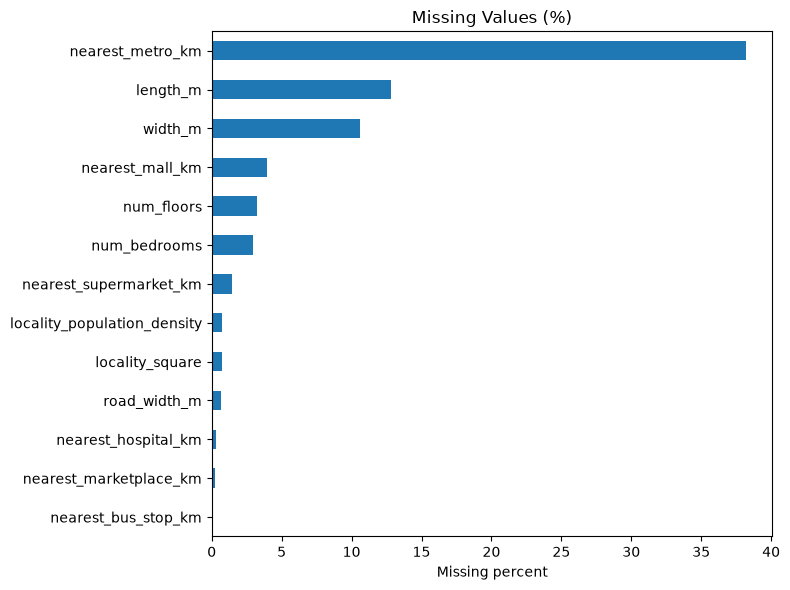

In [9]:
# Missing value chart for presentation/explanation.
missing_nonzero = missing_table[missing_table["missing_count"] > 0].sort_values("missing_percent")

if len(missing_nonzero) > 0:
    ax = missing_nonzero["missing_percent"].plot(
        kind="barh",
        figsize=(8, 6),
        title="Missing Values (%)",
    )
    ax.set_xlabel("Missing percent")
    plt.tight_layout()
else:
    print("No missing values found.")


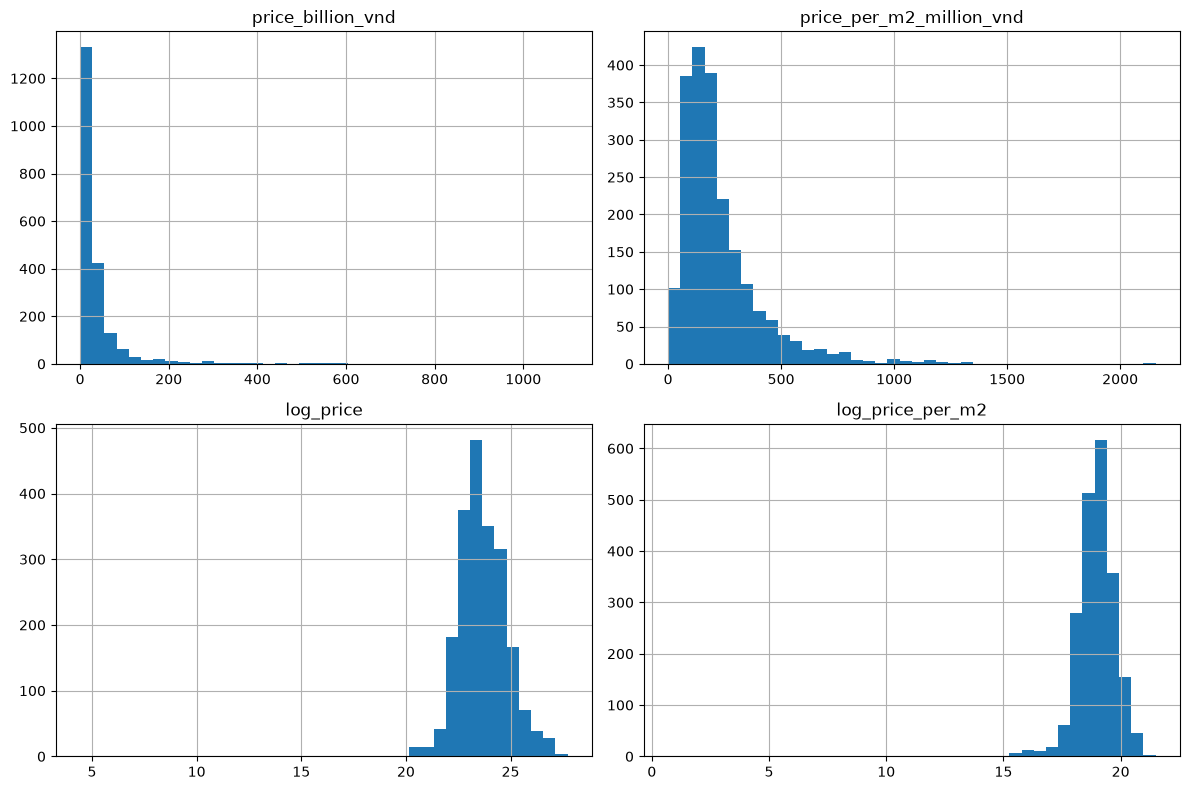

In [10]:
# Target distribution before modeling. Log scale helps reveal skew.
df_plot["log_price"] = np.log1p(df_plot["price_vnd"])
df_plot["log_price_per_m2"] = np.log1p(df_plot["price_per_m2"])

df_plot[["price_billion_vnd", "price_per_m2_million_vnd", "log_price", "log_price_per_m2"]].hist(
    bins=40,
    figsize=(12, 8),
)
plt.tight_layout()


In [11]:
# Show the exact outlier thresholds used by model_cleaning.py.
lower = df_plot["price_per_m2"].quantile(0.01)
upper = df_plot["price_per_m2"].quantile(0.99)

print(f"1st percentile price_per_m2: {lower / 1_000_000:,.1f} triệu VND/m2")
print(f"99th percentile price_per_m2: {upper / 1_000_000:,.1f} triệu VND/m2")
print(f"Rows outside threshold: {((df_plot['price_per_m2'] < lower) | (df_plot['price_per_m2'] > upper)).sum()}")


1st percentile price_per_m2: 12.5 triệu VND/m2
99th percentile price_per_m2: 1,000.0 triệu VND/m2
Rows outside threshold: 42


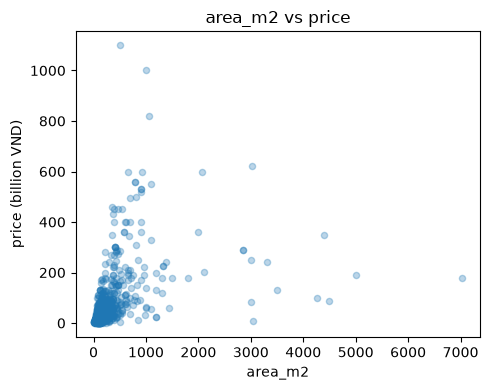

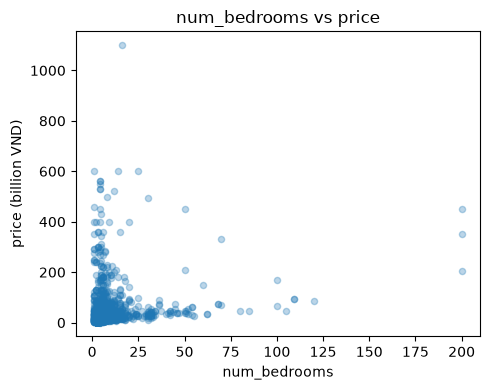

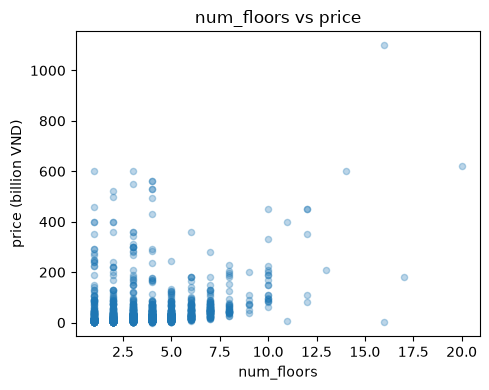

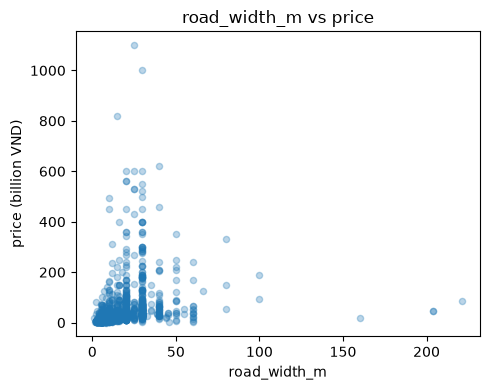

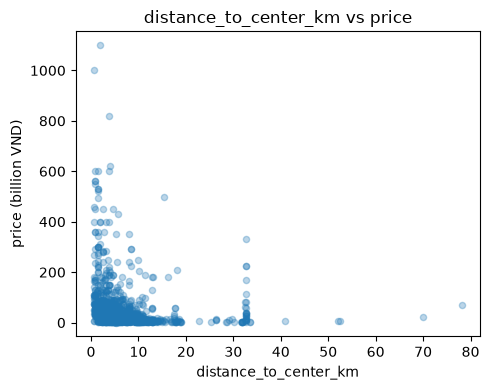

In [12]:
# Feature-target relationship checks.
feature_cols = [
    "area_m2",
    "num_bedrooms",
    "num_floors",
    "road_width_m",
    "distance_to_center_km",
]

for col in feature_cols:
    if col not in df_plot.columns:
        continue
    ax = df_plot.plot.scatter(
        x=col,
        y="price_billion_vnd",
        alpha=0.3,
        figsize=(5, 4),
        title=f"{col} vs price",
    )
    ax.set_ylabel("price (billion VND)")
    plt.tight_layout()
    plt.show()


In [13]:
# Categorical value counts to catch messy or rare categories.
for col in ["region", "locality", "property_type", "legal_status"]:
    if col not in df.columns:
        continue
    print()
    print(col)
    display(df[col].value_counts(dropna=False).head(20).to_frame("count"))



region


,count
region,
hồ chí minh,2082



locality


,count
locality,
phường bình lợi trung,143
phường tân bình,96
phường bình thạnh,76
phường thạnh mỹ tây,75
phường tân định,63
phường tân sơn,63
phường hòa hưng,62
phường gia định,58
phường bến thành,56



property_type


,count
property_type,
nha_mat_tien,1131
nha_trong_hem,951



legal_status


,count
legal_status,
so_hong_so_do,1387
unknown,659
giay_to_hop_le,36


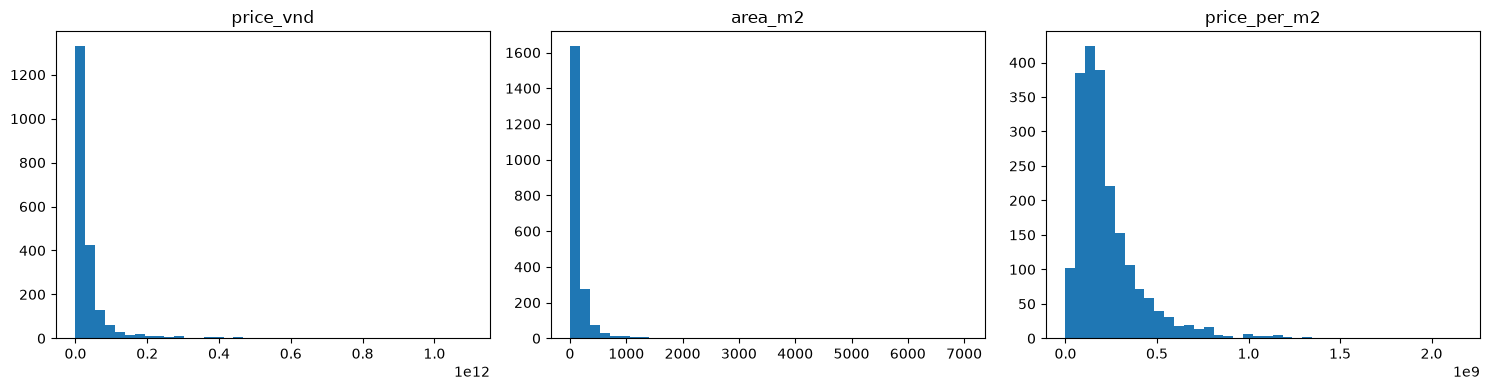

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["price_vnd", "area_m2", "price_per_m2"]):
    ax.hist(df_plot[col].dropna(), bins=40)
    ax.set_title(col)
plt.tight_layout()


In [15]:
top_cols = ["title", "street", "locality", "area_m2", "price_display", "price_per_m2_display"]
df_readable.sort_values("price_per_m2", ascending=False)[top_cols].head(20)


,title,street,locality,area_m2,price_display,price_per_m2_display
477,Cao ốc góc 2MT Nguyễn Đình Chiểu & Phan Kế Bín...,đường nguyễn đình chiểu,phường tân định,510.0,"1,100.00 tỷ","2,156.9 triệu"
262,"Duy nhất Ngang 22m MT Hàm Nghi, Quận 1 -Ngay c...",đường hàm nghi,phường sài gòn,343.0,460.00 tỷ,"1,341.1 triệu"
885,"Bán Nhà MT Lê Anh Xuân P.Bến Thành Q1, DT 5x15...",đường lê anh xuân,phường bến thành,75.0,100.00 tỷ,"1,333.3 triệu"
822,Tòa nhà góc 4MT - giao lộ Nguyễn Trãi & Cống Q...,đường nguyễn trãi,phường cầu ông lãnh,220.0,280.00 tỷ,"1,272.7 triệu"
1,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,đường lê thánh tôn,phường sài gòn,92.0,110.00 tỷ,"1,195.7 triệu"
7,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,đường lê thánh tôn,phường sài gòn,92.0,110.00 tỷ,"1,195.7 triệu"
2004,"Chỉ hơn 1,1 tỷ/m2 Mặt tiền Bến Nghé-- Mặt Tiền...",đường nguyễn du,phường sài gòn,364.0,430.00 tỷ,"1,181.3 triệu"
707,Bán nhà mặt tiền 25-27 Thủ Khoa Huân ngay Chợ ...,đường thủ khoa huân,phường bến thành,137.0,160.00 tỷ,"1,167.9 triệu"
95,"Siêu VIP Bến Thành, nhà 3 tầng, mặt tiền Ngô Đ...",đường ngô đức kế,phường sài gòn,85.0,99.00 tỷ,"1,164.7 triệu"
20,"Bán tòa nhà 369 B , Đường Nguyễn Trãi , phường...",đường nguyễn trãi,phường cầu ông lãnh,387.0,450.00 tỷ,"1,162.8 triệu"


In [16]:
df_readable.sort_values("price_per_m2", ascending=True)[top_cols].head(20)


,title,street,locality,area_m2,price_display,price_per_m2_display
1453,"SIÊU PHẨM! NHÀ PHỐ PHẠM VĂN ĐỒNG, P.13, BÌNH T...",đường phạm văn đồng,phường bình lợi trung,83.0,0.00 tỷ,0.0 triệu
137,"🔥 BÁN ĐẤT ĐẸP 3 MẶT TIỀN – TRUNG LẬP THƯỢNG, C...",đường bờ kênh,xã thái mỹ,3047.0,7.00 tỷ,2.3 triệu
310,Chính chủ bán nhà 179m2 (6x29m) ở Đ.Bàu Tre ở ...,đường bàu tre,xã tân an hội,179.0,0.82 tỷ,4.6 triệu
358,SIÊU PHẨM ĐÌNH ĐÁM TRUNG TÂM SÀI GÒN Q1,đường nguyễn đình chiểu,phường tân định,508.0,2.36 tỷ,4.6 triệu
75,"Bán nhà cấp 4, có 2 phòng ngủ tại Tân Phú Trun...",đường 12a,xã củ chi,131.0,0.83 tỷ,6.3 triệu
1269,📢 Nhà giá rẻ Tân Thông Hội Củ Chi. Diện tích 1...,đường lê thị sắc,xã củ chi,138.0,0.89 tỷ,6.4 triệu
1122,💥 BÁN NHANH TRONG 1 TUẦN GIÁ TỐT 870TRIEU - TÂ...,đường số 26,xã củ chi,129.0,0.87 tỷ,6.7 triệu
274,"Bán lô đất 230m2 Hồ Văng Tắng, Tân Phú Trung g...",đường hồ văn tắng,xã củ chi,230.0,1.59 tỷ,6.9 triệu
2071,"🏡 BÁN NHÀ CẤP 4 GIÁ CHỈ 650 TRIỆU – HẺM/QL50, ...",đường quốc lộ 50,xã bình hưng,90.0,0.65 tỷ,7.2 triệu
2000,Nhà mới xây xong không thích nữa bán rẻ lại 95...,đường lê minh nhựt,xã tân an hội,125.0,0.95 tỷ,7.6 triệu


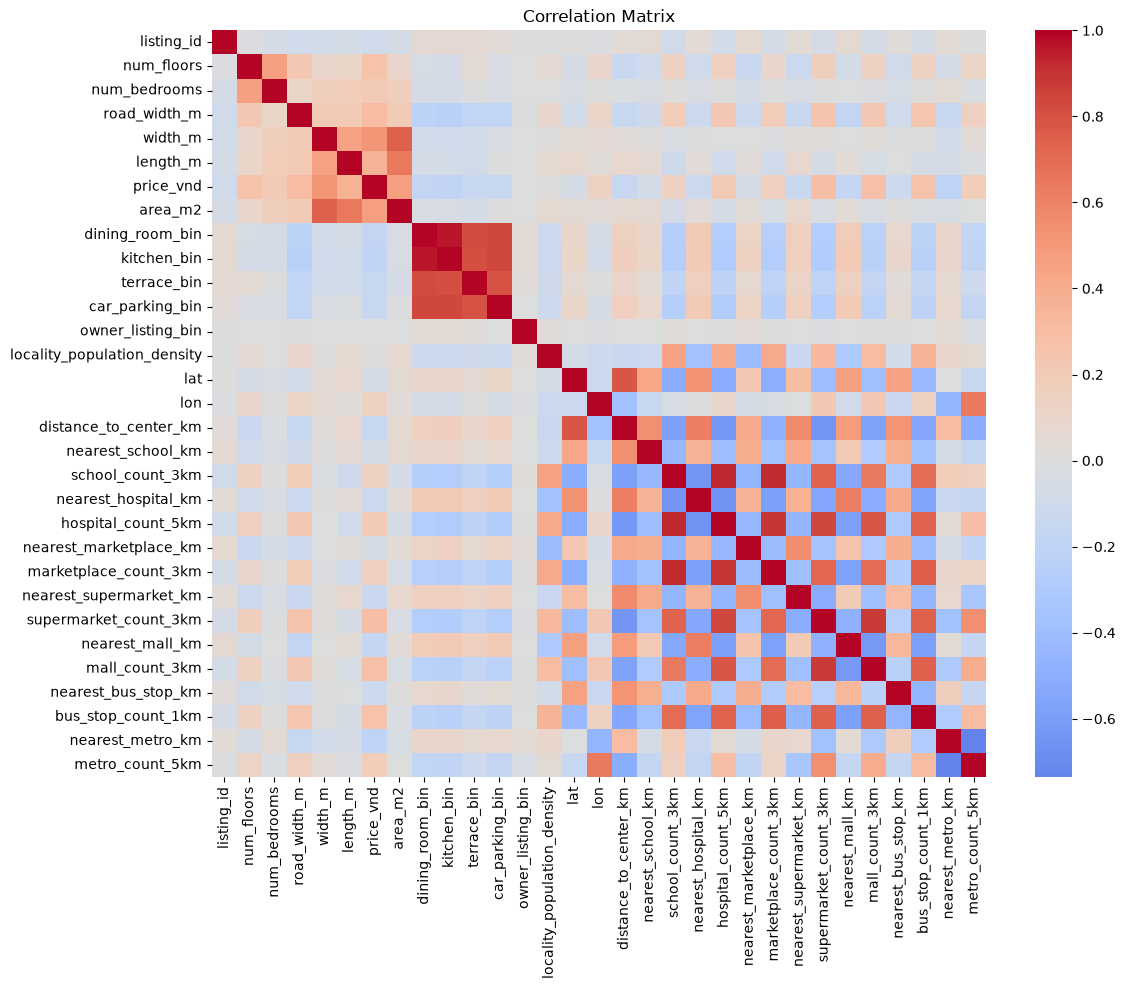

In [17]:
if sns is not None:
    corr_cols = [col for col in numeric_cols if df[col].nunique(dropna=True) > 1]
    corr = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Matrix")
    plt.tight_layout()
else:
    print("Install seaborn for the correlation heatmap.")


In [18]:
from model_cleaning import clean_for_modeling

cleaned = clean_for_modeling(df)
print(f"Rows: {len(df)} -> {len(cleaned)}")
print(f"Columns: {df.shape[1]} -> {cleaned.shape[1]}")
print(f"Missing values remaining: {int(cleaned.isna().sum().sum())}")
cleaned.head()


Rows: 2082 -> 1964
Columns: 44 -> 40
Missing values remaining: 0


,title,post_day,street,locality,region,direction,listing_type,property_type,legal_status,num_floors,...,marketplace_count_3km,nearest_supermarket_km,supermarket_count_3km,nearest_mall_km,mall_count_3km,nearest_bus_stop_km,bus_stop_count_1km,nearest_metro_km,metro_count_5km,price_per_m2
0,bán nhà riêng hẻm xe hơi 4 tầng mới đẹp lung l...,2026-05-23,đường lê quang định,phường bình thạnh,hồ chí minh,unknown,can_ban,nha_trong_hem,unknown,3.0,...,16.0,0.127429,61.0,3.067853,0.0,0.108269,47.0,2.080087,7.0,1.780000e+08
1,bán biệt thự khu compound 284 nguyễn trọng tuy...,2026-05-27,đường nguyễn trọng tuyển,phường phú nhuận,hồ chí minh,unknown,can_ban,nha_trong_hem,unknown,3.0,...,19.0,0.256364,53.0,1.945494,6.0,0.155312,47.0,3.900285,4.0,2.727273e+08
2,chủ sắp định cư nước ngoài giảm sốc 2 tỷ - bán...,2026-06-10,đường nguyễn phi khanh,phường tân định,hồ chí minh,unknown,can_ban,nha_mat_tien,so_hong_so_do,2.0,...,27.0,0.124817,100.0,1.475433,13.0,0.122047,50.0,2.031141,6.0,3.333333e+08
3,bán nhà thô tiện decor theo ý thích đường âu d...,2026-06-10,đường âu dương lân,phường chánh hưng,hồ chí minh,unknown,can_ban,nha_mat_tien,so_hong_so_do,6.0,...,41.0,0.011144,62.0,0.719246,10.0,0.221788,29.0,3.203954,3.0,1.457399e+08
4,vị trí đẹp nhất tuyến đường-mặt tiền trần hưng...,2026-06-10,đường trần hưng đạo,phường bến thành,hồ chí minh,unknown,can_ban,nha_mat_tien,so_hong_so_do,4.0,...,40.0,0.024305,101.0,0.382965,19.0,0.031166,104.0,0.170367,5.0,1.500000e+08


In [19]:
# Before vs after cleaning summary.
before_after = pd.DataFrame(
    {
        "raw": [len(df), df.shape[1], int(df.isna().sum().sum())],
        "cleaned": [len(cleaned), cleaned.shape[1], int(cleaned.isna().sum().sum())],
    },
    index=["rows", "columns", "missing_values"],
)

before_after


,raw,cleaned
rows,2082,1964
columns,44,40
missing_values,1584,0


In [20]:
cleaned.to_csv(CLEANED_PATH, index=False, encoding="utf-8-sig")
print(CLEANED_PATH)


d:\School\Kỳ 8\DSP391m\Codes\Real-Estate-Valuation\data\processed\real_estate_cleaned.csv
